<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/Natural_language_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1

In [1]:
from pathlib import Path
import shutil
import tarfile
from urllib.request import urlretrieve

archive_path = Path("aclImdb_v1.tar.gz")
dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not archive_path.exists():
    urlretrieve(dataset_url, archive_path)

if not Path("aclImdb").exists():
    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(".", filter="data")

shutil.rmtree("aclImdb/train/unsup", ignore_errors=True)
print(Path("aclImdb/README").read_text(encoding="utf-8")[:1_000])

Large Movie Review Dataset v1.0

Overview

This dataset contains movie reviews along with their associated binary
sentiment polarity labels. It is intended to serve as a benchmark for
sentiment classification. This document outlines how the dataset was
gathered, and how to use the files provided. 

Dataset 

The core dataset contains 50,000 reviews split evenly into 25k train
and 25k test sets. The overall distribution of labels is balanced (25k
pos and 25k neg). We also include an additional 50,000 unlabeled
documents for unsupervised learning. 

In the entire collection, no more than 30 reviews are allowed for any
given movie because reviews for the same movie tend to have correlated
ratings. Further, the train and test sets contain a disjoint set of
movies, so no significant performance is obtained by memorizing
movie-unique terms and their associated with observed labels.  In the
labeled train/test sets, a negative review has a score <= 4 out of 10,
and a positive review has a scor

In [2]:
from sklearn.datasets import load_files

train_review = load_files("aclImdb/train", encoding="utf-8", random_state=42)
test_review = load_files("aclImdb/test", encoding="utf-8", random_state=42)

x_train, y_train = train_review.data, train_review.target
x_test, y_test = test_review.data, test_review.target

print(train_review.target_names)
print(len(x_train), len(x_test))
print(x_train[0][:500])

['neg', 'pos']
25000 25000
Silent Night, Deadly Night 5 is the very last of the series, and like part 4, it's unrelated to the first three except by title and the fact that it's a Christmas-themed horror flick.<br /><br />Except to the oblivious, there's some obvious things going on here...Mickey Rooney plays a toymaker named Joe Petto and his creepy son's name is Pino. Ring a bell, anyone? Now, a little boy named Derek heard a knock at the door one evening, and opened it to find a present on the doorstep for him. Even th


In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

mini_dataset = [
    "This movie is very good.",
    "This film is a good",
    "Very bad. Very, very bad.",
]

count_vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
bow = count_vectorizer.fit_transform(mini_dataset)

bow_df = pd.DataFrame(
    bow.toarray(),
    columns=count_vectorizer.get_feature_names_out(),
)
display(bow_df)

,a,bad,film,good,is,movie,this,very
0,0,0,0,1,1,1,1,1
1,1,0,1,1,1,0,1,0
2,0,2,0,0,0,0,0,3


In [4]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b\w+\b",
)
bigram_bow = bigram_vectorizer.fit_transform(mini_dataset)

bigram_df = pd.DataFrame(
    bigram_bow.toarray(),
    columns=bigram_vectorizer.get_feature_names_out(),
)
display(bigram_df)

,a good,bad very,film is,is a,is very,movie is,this film,this movie,very bad,very good,very very
0,0,0,0,0,1,1,0,1,0,1,0
1,1,0,1,1,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,2,0,1


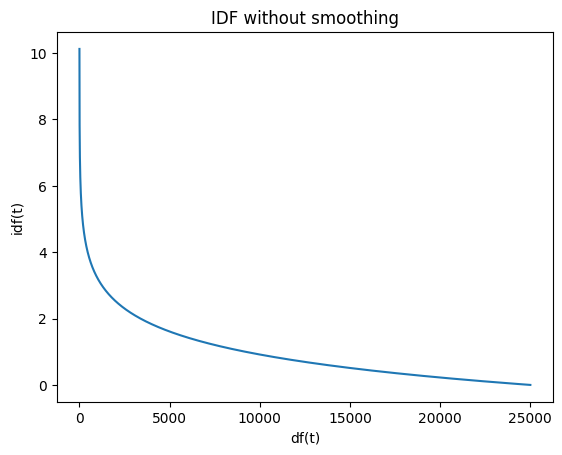

In [5]:
import matplotlib.pyplot as plt
import numpy as np

n_documents = 25_000
document_frequency = np.arange(1, n_documents + 1)
idf = np.log(n_documents / document_frequency)

plt.plot(document_frequency, idf)
plt.title("IDF without smoothing")
plt.xlabel("df(t)")
plt.ylabel("idf(t)")
plt.show()

In [6]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
english_stop_words = stopwords.words("english")
print(english_stop_words[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [7]:
limited_vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b\w+\b",
    stop_words=["is"],
    max_features=5,
)
limited_bow = limited_vectorizer.fit_transform(mini_dataset)

limited_df = pd.DataFrame(
    limited_bow.toarray(),
    columns=limited_vectorizer.get_feature_names_out(),
)
display(limited_df)

,bad,film,good,this,very
0,0,0,1,1,1
1,0,1,1,1,0
2,2,0,0,0,3


In [ ]:
## Problem 2

In [8]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import load_files

# 1. Load data
train_review = load_files("aclImdb/train", encoding="utf-8", random_state=42)
test_review  = load_files("aclImdb/test",  encoding="utf-8", random_state=42)

x_train, y_train = train_review.data, train_review.target
x_test,  y_test  = test_review.data,  test_review.target

# 2. Get NLTK English stop words
nltk.download("stopwords", quiet=True)
english_stop_words = stopwords.words("english")

# 3. Build the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    stop_words=english_stop_words,
    max_features=5_000,
    # defaults: smooth_idf=True, sublinear_tf=False, norm="l2"
)

# 4. Fit ONLY on training data, then transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
X_test_tfidf  = tfidf_vectorizer.transform(x_test)

# 5. Inspect
print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))
print("First 20 features:", tfidf_vectorizer.get_feature_names_out()[:20])

Train shape: (25000, 5000)
Test shape : (25000, 5000)
Vocabulary size: 5000
First 20 features: ['00' '000' '10' '100' '11' '12' '13' '13th' '14' '15' '16' '17' '18'
 '1930' '1930s' '1933' '1940' '1950' '1950s' '1960']


In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Step 1: Count tokens (fit on train only)
count_vectorizer = CountVectorizer(
    stop_words=english_stop_words,
    max_features=5_000,
)
X_train_counts = count_vectorizer.fit_transform(x_train)
X_test_counts  = count_vectorizer.transform(x_test)

# Step 2: Convert counts to TF-IDF weights (fit on train only)
tfidf_transformer = TfidfTransformer()   # smooth_idf=True, norm="l2" by default
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_test_tfidf  = tfidf_transformer.transform(X_test_counts)

print("Train shape:", X_train_tfidf.shape)
print("Test shape :", X_test_tfidf.shape)

Train shape: (25000, 5000)
Test shape : (25000, 5000)


In [10]:
import numpy as np

# Check sparsity (most entries should be zero)
print("Non-zero entries in train:", X_train_tfidf.nnz)
print("Sparsity: %.4f" % (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])))

# Check row norms (should all be ~1.0 due to L2 norm)
row_norms = np.sqrt(X_train_tfidf.multiply(X_train_tfidf).sum(axis=1))
print("Row norm — min:", row_norms.min(), "max:", row_norms.max())

# Look at a single review's top-weighted words
feature_names = tfidf_vectorizer.get_feature_names_out()
doc_index = 0
row = X_train_tfidf[doc_index].toarray().flatten()
top_indices = row.argsort()[::-1][:10]
print(f"\nTop TF-IDF terms in review {doc_index} (label={y_train[doc_index]}):")
for i in top_indices:
    print(f"  {feature_names[i]:20s} {row[i]:.4f}")

Non-zero entries in train: 1999647
Sparsity: 0.9840
Row norm — min: 0.9999999999999991 max: 1.000000000000001

Top TF-IDF terms in review 0 (label=0):
  derek                0.2569
  joe                  0.1994
  course               0.1780
  toys                 0.1702
  gift                 0.1641
  santa                0.1622
  anyway               0.1621
  larry                0.1607
  toy                  0.1594
  stranger             0.1590


In [11]:
# The IDF vector learned from training data
idf_values = tfidf_transformer.idf_ if 'tfidf_transformer' in dir() else tfidf_vectorizer.idf_

# Lowest IDF = most frequent / least informative tokens
sorted_idx = np.argsort(idf_values)
print("Lowest IDF (most common):")
for i in sorted_idx[:10]:
    print(f"  {feature_names[i]:20s} idf={idf_values[i]:.4f}")

print("\nHighest IDF (rarest within max_features):")
for i in sorted_idx[-10:]:
    print(f"  {feature_names[i]:20s} idf={idf_values[i]:.4f}")

Lowest IDF (most common):
  movie                idf=1.4903
  br                   idf=1.5333
  one                  idf=1.5681
  film                 idf=1.5839
  like                 idf=1.7612
  good                 idf=1.9528
  time                 idf=2.0516
  even                 idf=2.0883
  would                idf=2.1231
  see                  idf=2.1273

Highest IDF (rarest within max_features):
  fido                 idf=7.8686
  timon                idf=7.8686
  din                  idf=7.8686
  rukh                 idf=7.9078
  antwone              idf=7.9078
  carla                idf=8.0356
  gundam               idf=8.0356
  biko                 idf=8.0356
  zizek                idf=8.4186
  macarthur            idf=8.6418


In [12]:
import scipy.sparse as sp

sp.save_npz("X_train_tfidf.npz", X_train_tfidf)
sp.save_npz("X_test_tfidf.npz",  X_test_tfidf)
np.save("y_train.npy", y_train)
np.save("y_test.npy",  y_test)

# Later:
X_train_tfidf = sp.load_npz("X_train_tfidf.npz")

In [ ]:
## Problem 3

In [13]:
import numpy as np
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

# Load raw data
train_review = load_files("aclImdb/train", encoding="utf-8", random_state=42)
test_review  = load_files("aclImdb/test",  encoding="utf-8", random_state=42)

x_train_full, y_train_full = train_review.data, train_review.target
x_test,       y_test       = test_review.data,  test_review.target

# Split training data into train / validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,          # 20% for validation
    random_state=42,
    stratify=y_train_full,  # keep class balance
)

print("Train:", len(x_train))
print("Val  :", len(x_val))
print("Test :", len(x_test))

Train: 20000
Val  : 5000
Test : 25000


In [14]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords", quiet=True)
english_stop_words = stopwords.words("english")

tfidf_vectorizer = TfidfVectorizer(
    stop_words=english_stop_words,
    max_features=5_000,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(x_train)   # fit + transform
X_val_tfidf   = tfidf_vectorizer.transform(x_val)         # transform only
X_test_tfidf  = tfidf_vectorizer.transform(x_test)        # transform only

print("Train:", X_train_tfidf.shape)
print("Val  :", X_val_tfidf.shape)
print("Test :", X_test_tfidf.shape)

Train: (20000, 5000)
Val  : (5000, 5000)
Test : (25000, 5000)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

clf = LogisticRegression(max_iter=1000, random_state=42)

t0 = time.time()
clf.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

# Validation performance
y_val_pred = clf.predict(X_val_tfidf)

print(f"Training time: {train_time:.2f} s")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation F1 (binary): {f1_score(y_val, y_val_pred):.4f}")
print()
print(classification_report(y_val, y_val_pred, target_names=train_review.target_names))

Training time: 0.80 s
Validation accuracy: 0.8848
Validation F1 (binary): 0.8864

              precision    recall  f1-score   support

         neg       0.90      0.87      0.88      2500
         pos       0.87      0.90      0.89      2500

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



In [16]:
y_test_pred = clf.predict(X_test_tfidf)

print("Final test accuracy:", accuracy_score(y_test, y_test_pred))
print("Final test F1 (binary):", f1_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred, target_names=test_review.target_names))

Final test accuracy: 0.88068
Final test F1 (binary): 0.881273631840796

              precision    recall  f1-score   support

         neg       0.88      0.88      0.88     12500
         pos       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [17]:
def run_experiment(name, vectorizer, x_train, y_train, x_val, y_val):
    # Vectorize
    t0 = time.time()
    X_train_v = vectorizer.fit_transform(x_train)
    X_val_v   = vectorizer.transform(x_val)
    vec_time = time.time() - t0

    vocab_size = len(vectorizer.vocabulary_)

    # Train
    clf = LogisticRegression(max_iter=1000, random_state=42)
    t1 = time.time()
    clf.fit(X_train_v, y_train)
    train_time = time.time() - t1

    # Evaluate
    y_val_pred = clf.predict(X_val_v)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred)

    print(f"--- {name} ---")
    print(f"  Vocab size      : {vocab_size}")
    print(f"  Vectorize time  : {vec_time:.2f} s")
    print(f"  Train time      : {train_time:.2f} s")
    print(f"  Val accuracy    : {acc:.4f}")
    print(f"  Val F1          : {f1:.4f}")
    print()

    return {
        "name": name,
        "vocab_size": vocab_size,
        "vec_time": vec_time,
        "train_time": train_time,
        "accuracy": acc,
        "f1": f1,
    }

In [18]:
results = []

for mf in [1_000, 5_000, 20_000, None]:   # None = no cap
    vec = TfidfVectorizer(
        stop_words=english_stop_words,
        max_features=mf,
    )
    label = f"max_features={mf}"
    results.append(run_experiment(label, vec, x_train, y_train, x_val, y_val))

--- max_features=1000 ---
  Vocab size      : 1000
  Vectorize time  : 10.85 s
  Train time      : 0.32 s
  Val accuracy    : 0.8532
  Val F1          : 0.8554

--- max_features=5000 ---
  Vocab size      : 5000
  Vectorize time  : 6.22 s
  Train time      : 0.47 s
  Val accuracy    : 0.8848
  Val F1          : 0.8864

--- max_features=20000 ---
  Vocab size      : 20000
  Vectorize time  : 5.42 s
  Train time      : 1.80 s
  Val accuracy    : 0.8890
  Val F1          : 0.8909

--- max_features=None ---
  Vocab size      : 68412
  Vectorize time  : 5.86 s
  Train time      : 2.47 s
  Val accuracy    : 0.8894
  Val F1          : 0.8913



In [19]:
for sw in [None, "english"]:   # None = keep all words
    vec = TfidfVectorizer(
        stop_words=sw,
        max_features=5_000,
    )
    label = f"stop_words={sw}"
    results.append(run_experiment(label, vec, x_train, y_train, x_val, y_val))

--- stop_words=None ---
  Vocab size      : 5000
  Vectorize time  : 10.00 s
  Train time      : 0.68 s
  Val accuracy    : 0.8804
  Val F1          : 0.8824

--- stop_words=english ---
  Vocab size      : 5000
  Vectorize time  : 4.93 s
  Train time      : 0.28 s
  Val accuracy    : 0.8774
  Val F1          : 0.8793



In [20]:
# Check whether negations are in the stop-word list
negations = {"not", "no", "nor", "never", "none", "nothing", "neither"}
print("Negations in NLTK stop words:", negations & set(english_stop_words))

Negations in NLTK stop words: {'nor', 'no', 'not'}


In [21]:
for ng in [(1, 1), (1, 2), (2, 2)]:
    vec = TfidfVectorizer(
        stop_words=english_stop_words,
        max_features=5_000,
        ngram_range=ng,
    )
    label = f"ngram_range={ng}"
    results.append(run_experiment(label, vec, x_train, y_train, x_val, y_val))

--- ngram_range=(1, 1) ---
  Vocab size      : 5000
  Vectorize time  : 7.44 s
  Train time      : 0.46 s
  Val accuracy    : 0.8848
  Val F1          : 0.8864

--- ngram_range=(1, 2) ---
  Vocab size      : 5000
  Vectorize time  : 20.39 s
  Train time      : 0.39 s
  Val accuracy    : 0.8798
  Val F1          : 0.8816

--- ngram_range=(2, 2) ---
  Vocab size      : 5000
  Vectorize time  : 16.14 s
  Train time      : 0.08 s
  Val accuracy    : 0.8056
  Val F1          : 0.8085



In [22]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("accuracy", ascending=False)
display(results_df)

,name,vocab_size,vec_time,train_time,accuracy,f1
3,max_features=None,68412,5.858661,2.466482,0.8894,0.891334
2,max_features=20000,20000,5.419472,1.800093,0.8890,0.890898
1,max_features=5000,5000,6.221105,0.470661,0.8848,0.886435
6,"ngram_range=(1, 1)",5000,7.442926,0.459274,0.8848,0.886435
4,stop_words=None,5000,10.000361,0.679514,0.8804,0.882376
7,"ngram_range=(1, 2)",5000,20.391732,0.394222,0.8798,0.881623
5,stop_words=english,5000,4.928445,0.278560,0.8774,0.879307
0,max_features=1000,1000,10.846394,0.322202,0.8532,0.855398
8,"ngram_range=(2, 2)",5000,16.136724,0.077790,0.8056,0.808511


In [23]:
# Suppose ngram_range=(1,2) won on validation
best_vectorizer = TfidfVectorizer(
    stop_words=english_stop_words,
    max_features=5_000,
    ngram_range=(1, 2),
)

X_train_best = best_vectorizer.fit_transform(x_train)
X_val_best   = best_vectorizer.transform(x_val)
X_test_best  = best_vectorizer.transform(x_test)

best_clf = LogisticRegression(max_iter=1000, random_state=42)
best_clf.fit(X_train_best, y_train)

# Validation check
y_val_pred = best_clf.predict(X_val_best)
print("Best model — validation accuracy:", accuracy_score(y_val, y_val_pred))

# Final test evaluation (one time only)
y_test_pred = best_clf.predict(X_test_best)
print("Best model — test accuracy    :", accuracy_score(y_test, y_test_pred))
print("Best model — test F1          :", f1_score(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred, target_names=test_review.target_names))

Best model — validation accuracy: 0.8798
Best model — test accuracy    : 0.8828
Best model — test F1          : 0.8834990059642147

              precision    recall  f1-score   support

         neg       0.89      0.88      0.88     12500
         pos       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [24]:
feature_names = best_vectorizer.get_feature_names_out()
coefs = best_clf.coef_.flatten()

top_positive = np.argsort(coefs)[::-1][:20]
top_negative = np.argsort(coefs)[:20]

print("Top POSITIVE features:")
for i in top_positive:
    print(f"  {feature_names[i]:25s} {coefs[i]:+.4f}")

print("\nTop NEGATIVE features:")
for i in top_negative:
    print(f"  {feature_names[i]:25s} {coefs[i]:+.4f}")

Top POSITIVE features:
  great                     +5.7672
  excellent                 +5.1789
  perfect                   +4.3430
  wonderful                 +4.0477
  amazing                   +4.0236
  best                      +3.9498
  favorite                  +3.6530
  today                     +3.4064
  loved                     +3.3498
  enjoyable                 +3.2863
  fun                       +3.2839
  well                      +3.0957
  brilliant                 +3.0757
  superb                    +3.0613
  definitely                +3.0451
  bit                       +3.0315
  fantastic                 +2.9867
  love                      +2.9717
  still                     +2.7688
  enjoy                     +2.7440

Top NEGATIVE features:
  worst                     -7.3818
  awful                     -6.2673
  bad                       -6.1226
  boring                    -5.4990
  waste                     -5.2591
  poor                      -4.4841
  worse          

In [25]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC":          LinearSVC(random_state=42),
    "MultinomialNB":      MultinomialNB(),
    "SGDClassifier":      SGDClassifier(random_state=42),
}

for name, clf in classifiers.items():
    t0 = time.time()
    clf.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0
    y_val_pred = clf.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_val_pred)
    f1  = f1_score(y_val, y_val_pred)
    print(f"{name:20s} train={train_time:.2f}s  acc={acc:.4f}  f1={f1:.4f}")

LogisticRegression   train=1.08s  acc=0.8848  f1=0.8864
LinearSVC            train=0.68s  acc=0.8690  f1=0.8700
MultinomialNB        train=0.02s  acc=0.8480  f1=0.8491
SGDClassifier        train=0.19s  acc=0.8846  f1=0.8862


In [ ]:
## Problem 4

In [26]:
import re
import math
import pandas as pd
from collections import Counter

# ---------- Input documents ----------
documents = [
    "This movie is SOOOO funny!!!",
    "What a movie! I never",
    "best movie ever!!!!! this movie",
]

# ---------- Preprocess: lowercase, remove punctuation, split on whitespace ----------
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)   # keep only word chars and whitespace
    return text.split()

tokenized = [preprocess(doc) for doc in documents]

# ---------- Vocabulary (sorted for reproducibility) ----------
vocabulary = sorted({token for doc in tokenized for token in doc})
N = len(documents)   # number of documents

# ---------- Term counts per document ----------
term_counts = [Counter(doc) for doc in tokenized]

# ---------- Document frequency: df(t) = # docs containing t ----------
df = {t: sum(1 for tc in term_counts if tc.get(t, 0) > 0) for t in vocabulary}

# ---------- Display ----------
print("Tokenized documents:")
for i, tokens in enumerate(tokenized, start=1):
    print(f"  D{i}: {tokens}")

print("\nVocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))

print("\nTerm count table:")
count_table = pd.DataFrame(
    [[tc.get(t, 0) for t in vocabulary] for tc in term_counts],
    index=[f"D{i}" for i in range(1, N + 1)],
    columns=vocabulary,
)
display(count_table)

print("\nDocument frequency table:")
df_table = pd.DataFrame(
    {"df": [df[t] for t in vocabulary]},
    index=vocabulary,
)
display(df_table)

# Save for the next codes
import pickle
with open("tfidf_state.pkl", "wb") as f:
    pickle.dump({
        "documents": documents,
        "tokenized": tokenized,
        "vocabulary": vocabulary,
        "N": N,
        "term_counts": term_counts,
        "df": df,
    }, f)

print("\nState saved to tfidf_state.pkl")

Tokenized documents:
  D1: ['this', 'movie', 'is', 'soooo', 'funny']
  D2: ['what', 'a', 'movie', 'i', 'never']
  D3: ['best', 'movie', 'ever', 'this', 'movie']

Vocabulary: ['a', 'best', 'ever', 'funny', 'i', 'is', 'movie', 'never', 'soooo', 'this', 'what']
Vocabulary size: 11

Term count table:


,a,best,ever,funny,i,is,movie,never,soooo,this,what
D1,0,0,0,1,0,1,1,0,1,1,0
D2,1,0,0,0,1,0,1,1,0,0,1
D3,0,1,1,0,0,0,2,0,0,1,0



Document frequency table:


,df
a,1
best,1
ever,1
funny,1
i,1
is,1
movie,3
never,1
soooo,1
this,2



State saved to tfidf_state.pkl


In [27]:
import math
import pickle
import pandas as pd

# ---------- Load state from Code 1 ----------
with open("tfidf_state.pkl", "rb") as f:
    state = pickle.load(f)

vocabulary   = state["vocabulary"]
N            = state["N"]
term_counts  = state["term_counts"]
df           = state["df"]

# ---------- Standard formulas ----------
# TF(t,d)    = n_{t,d} / sum_s n_{s,d}
# IDF(t)     = log(N / df(t))
# TFIDF(t,d) = TF(t,d) * IDF(t)

def tf_standard(tc, vocab):
    total = sum(tc.values())
    return {t: tc.get(t, 0) / total for t in vocab}

idf_standard = {t: math.log(N / df[t]) for t in vocabulary}

tfidf_standard = [
    {t: tf_standard(tc, vocabulary)[t] * idf_standard[t] for t in vocabulary}
    for tc in term_counts
]

# ---------- Tables ----------
idf_std_df = pd.DataFrame(
    {"df": [df[t] for t in vocabulary],
     "idf": [idf_standard[t] for t in vocabulary]},
    index=vocabulary,
).round(4)

tfidf_std_df = pd.DataFrame(
    [[row[t] for t in vocabulary] for row in tfidf_standard],
    index=[f"D{i}" for i in range(1, N + 1)],
    columns=vocabulary,
).round(4)

print("=== Standard IDF (log(N/df)) ===")
display(idf_std_df)

print("\n=== Standard TF-IDF (normalized TF × standard IDF) ===")
display(tfidf_std_df)

=== Standard IDF (log(N/df)) ===


,df,idf
a,1,1.0986
best,1,1.0986
ever,1,1.0986
funny,1,1.0986
i,1,1.0986
is,1,1.0986
movie,3,0.0000
never,1,1.0986
soooo,1,1.0986
this,2,0.4055



=== Standard TF-IDF (normalized TF × standard IDF) ===


,a,best,ever,funny,i,is,movie,never,soooo,this,what
D1,0.0000,0.0000,0.0000,0.2197,0.0000,0.2197,0.0,0.0000,0.2197,0.0811,0.0000
D2,0.2197,0.0000,0.0000,0.0000,0.2197,0.0000,0.0,0.2197,0.0000,0.0000,0.2197
D3,0.0000,0.2197,0.2197,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0811,0.0000


In [28]:
import math
import pickle
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------- Load state from Code 1 ----------
with open("tfidf_state.pkl", "rb") as f:
    state = pickle.load(f)

documents    = state["documents"]
tokenized    = state["tokenized"]
vocabulary   = state["vocabulary"]
N            = state["N"]
term_counts  = state["term_counts"]
df           = state["df"]

# ---------- scikit-learn default formulas ----------
# TF(t,d)    = n_{t,d}                          (raw count)
# IDF(t)     = log((1 + N) / (1 + df(t))) + 1   (smoothed)
# TFIDF(t,d) = n_{t,d} * IDF(t)

def idf_smoothed(df_dict, N):
    return {t: math.log((1 + N) / (1 + df_dict[t])) + 1 for t in df_dict}

idf_sm = idf_smoothed(df, N)

tfidf_sm = [
    {t: tc.get(t, 0) * idf_sm[t] for t in vocabulary}
    for tc in term_counts
]

# ---------- Tables ----------
idf_sm_df = pd.DataFrame(
    {"df": [df[t] for t in vocabulary],
     "idf_smoothed": [idf_sm[t] for t in vocabulary]},
    index=vocabulary,
).round(4)

tfidf_sm_df = pd.DataFrame(
    [[row[t] for t in vocabulary] for row in tfidf_sm],
    index=[f"D{i}" for i in range(1, N + 1)],
    columns=vocabulary,
).round(4)

print("=== scikit-learn-style smoothed IDF ===")
display(idf_sm_df)

print("\n=== scikit-learn-style TF-IDF (raw TF × smoothed IDF, no L2 norm) ===")
display(tfidf_sm_df)

# ---------- Verification against scikit-learn ----------
sk_vec = TfidfVectorizer(
    analyzer=lambda doc: doc,   # input is already a list of tokens
    norm=None,                  # disable L2 normalization
    smooth_idf=True,
    sublinear_tf=False,
)
X_sk = sk_vec.fit_transform(tokenized).toarray()

sk_df = pd.DataFrame(
    X_sk,
    index=[f"D{i}" for i in range(1, N + 1)],
    columns=sk_vec.get_feature_names_out(),
).round(4)

print("\n=== scikit-learn reference (norm=None) ===")
display(sk_df)

# Align columns and compare
scratch_aligned = tfidf_sm_df[sk_vec.get_feature_names_out()]
max_diff = np.abs(scratch_aligned.values - sk_df.values).max()
print(f"\nMax absolute difference vs scikit-learn: {max_diff:.2e}")
print("Match!" if max_diff < 1e-9 else "Mismatch — check tokenization / formulas")

=== scikit-learn-style smoothed IDF ===


,df,idf_smoothed
a,1,1.6931
best,1,1.6931
ever,1,1.6931
funny,1,1.6931
i,1,1.6931
is,1,1.6931
movie,3,1.0000
never,1,1.6931
soooo,1,1.6931
this,2,1.2877



=== scikit-learn-style TF-IDF (raw TF × smoothed IDF, no L2 norm) ===


,a,best,ever,funny,i,is,movie,never,soooo,this,what
D1,0.0000,0.0000,0.0000,1.6931,0.0000,1.6931,1.0,0.0000,1.6931,1.2877,0.0000
D2,1.6931,0.0000,0.0000,0.0000,1.6931,0.0000,1.0,1.6931,0.0000,0.0000,1.6931
D3,0.0000,1.6931,1.6931,0.0000,0.0000,0.0000,2.0,0.0000,0.0000,1.2877,0.0000



=== scikit-learn reference (norm=None) ===


,a,best,ever,funny,i,is,movie,never,soooo,this,what
D1,0.0000,0.0000,0.0000,1.6931,0.0000,1.6931,1.0,0.0000,1.6931,1.2877,0.0000
D2,1.6931,0.0000,0.0000,0.0000,1.6931,0.0000,1.0,1.6931,0.0000,0.0000,1.6931
D3,0.0000,1.6931,1.6931,0.0000,0.0000,0.0000,2.0,0.0000,0.0000,1.2877,0.0000



Max absolute difference vs scikit-learn: 0.00e+00
Match!


In [ ]:
## Problem 5

In [29]:
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

train_review = load_files("aclImdb/train", encoding="utf-8", random_state=42)
test_review  = load_files("aclImdb/test",  encoding="utf-8", random_state=42)

x_train_full, y_train_full = train_review.data, train_review.target
x_test,       y_test       = test_review.data,  test_review.target

# Same split as Problem 3 for consistency
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print("Train:", len(x_train))
print("Val  :", len(x_val))
print("Test :", len(x_test))

Train: 20000
Val  : 5000
Test : 25000


In [30]:
for i in range(3):
    print(f"--- Review {i} (label={y_train[i]}) ---")
    print(x_train[i][:600])
    print()

--- Review 0 (label=1) ---
This zippy and fun short from 1916 - the time when Charlie Chaplin and Fatty Arbuckle were the big names in comedy - features the young Oliver Hardy as a ne'er-do-well who has to quickly impress his wealthy uncle by producing a wife and baby for his visit.<br /><br />Of course this does not go smoothly and soon there are rather more wives and babies than he can cope with; plus the mandatory chases and misunderstandings that are the hallmark of early movie slapstick.<br /><br />Restored well it can be viewed as part of 'The Early Films of Oliver Hardy' and is now available on DVD, a fine additi

--- Review 1 (label=0) ---
Yikes. This is pretty bad. The play isn't great to begin with, and the decision to transfer it to film does it no favours - especially as Peploe doesn't decide how she wants to treat the material's theatrical origins (we get occasional glances of an observing theatre audience etc.) and has decided to go with a jumpy editing style that is inte

In [31]:
import re

# Precompiled regexes (faster than re-compiling per call)
HTML_RE = re.compile(r"<[^>]+>")                 # <br />, <p>, etc.
URL_RE  = re.compile(r"https?://\S+|www\.\S+")   # http(s)://... and www...
PUNCT_RE = re.compile(r"[^\w\s]")                # punctuation → space
TOKEN_RE = re.compile(r"\b\w+\b")                # token pattern

def preprocess(text):
    """
    Lowercase, strip HTML/URLs, replace punctuation with space,
    then tokenize with regex.
    """
    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = PUNCT_RE.sub(" ", text)      # 'don't' → 'don t'
    tokens = TOKEN_RE.findall(text)     # ['don', 't']
    return tokens

In [32]:
tokenized_train = [preprocess(doc) for doc in x_train]
tokenized_val   = [preprocess(doc) for doc in x_val]
tokenized_test  = [preprocess(doc) for doc in x_test]

print("Train size:", len(tokenized_train))
print("Example  :", tokenized_train[0][:30])

Train size: 20000
Example  : ['this', 'zippy', 'and', 'fun', 'short', 'from', '1916', 'the', 'time', 'when', 'charlie', 'chaplin', 'and', 'fatty', 'arbuckle', 'were', 'the', 'big', 'names', 'in', 'comedy', 'features', 'the', 'young', 'oliver', 'hardy', 'as', 'a', 'ne', 'er']


In [33]:
for i in range(3):
    print(f"========== Review {i} (label={y_train[i]}) ==========")
    print("RAW (first 300 chars):")
    print(x_train[i][:300])
    print()
    print("TOKENS (first 30):")
    print(tokenized_train[i][:30])
    print(f"Total tokens: {len(tokenized_train[i])}")
    print()

========== Review 0 (label=1) ==========
RAW (first 300 chars):
This zippy and fun short from 1916 - the time when Charlie Chaplin and Fatty Arbuckle were the big names in comedy - features the young Oliver Hardy as a ne'er-do-well who has to quickly impress his wealthy uncle by producing a wife and baby for his visit.<br /><br />Of course this does not go smoot

TOKENS (first 30):
['this', 'zippy', 'and', 'fun', 'short', 'from', '1916', 'the', 'time', 'when', 'charlie', 'chaplin', 'and', 'fatty', 'arbuckle', 'were', 'the', 'big', 'names', 'in', 'comedy', 'features', 'the', 'young', 'oliver', 'hardy', 'as', 'a', 'ne', 'er']
Total tokens: 119

========== Review 1 (label=0) ==========
RAW (first 300 chars):
Yikes. This is pretty bad. The play isn't great to begin with, and the decision to transfer it to film does it no favours - especially as Peploe doesn't decide how she wants to treat the material's theatrical origins (we get occasional glances of an observing theatre audience etc.) an

In [34]:
import numpy as np
from collections import Counter

# Token counts (train only)
token_counter = Counter(tok for doc in tokenized_train for tok in doc)

total_tokens    = sum(token_counter.values())
unique_tokens   = len(token_counter)
avg_doc_length  = np.mean([len(doc) for doc in tokenized_train])
min_doc_length  = min(len(doc) for doc in tokenized_train)
max_doc_length  = max(len(doc) for doc in tokenized_train)

print(f"Total tokens (train)     : {total_tokens:,}")
print(f"Unique tokens (train)    : {unique_tokens:,}")
print(f"Avg tokens per review    : {avg_doc_length:.1f}")
print(f"Min / max tokens/review  : {min_doc_length} / {max_doc_length}")

Total tokens (train)     : 4,768,741
Unique tokens (train)    : 68,500
Avg tokens per review    : 238.4
Min / max tokens/review  : 10 / 2505


In [35]:
# Top 20 most frequent tokens
print("Top 20 most frequent tokens:")
for tok, cnt in token_counter.most_common(20):
    print(f"  {tok:12s} {cnt}")

Top 20 most frequent tokens:
  the          269874
  and          131376
  a            130565
  of           116602
  to           108766
  is           86278
  it           77057
  in           75310
  i            69978
  this         60901
  that         58903
  s            50996
  was          38568
  as           37507
  for          35534
  with         35145
  movie        35140
  but          34232
  film         32137
  t            27623


In [36]:
counts = np.array(list(token_counter.values()))

for threshold in [1, 2, 3, 5, 10]:
    n_below = (counts < threshold).sum()
    print(f"Tokens with count < {threshold:2d}: {n_below:,} "
          f"({100 * n_below / unique_tokens:.1f}% of vocab)")

Tokens with count <  1: 0 (0.0% of vocab)
Tokens with count <  2: 25,485 (37.2% of vocab)
Tokens with count <  3: 33,898 (49.5% of vocab)
Tokens with count <  5: 42,191 (61.6% of vocab)
Tokens with count < 10: 50,557 (73.8% of vocab)


In [37]:
negations = {"not", "no", "never", "none", "nothing",
             "neither", "nor", "n", "t", "cannot", "without"}

negation_counts = {neg: token_counter.get(neg, 0) for neg in negations}

print("Negation token counts (train):")
for neg, cnt in sorted(negation_counts.items(), key=lambda x: -x[1]):
    print(f"  {neg:10s} {cnt}")

Negation token counts (train):
  t          27623
  not        24684
  no         10195
  never      5215
  nothing    3465
  without    2637
  cannot     886
  none       820
  nor        550
  neither    430
  n          221


In [38]:
import re

html_left = sum(1 for doc in tokenized_train for tok in doc if re.search(r"[<>]", tok))
url_left  = sum(1 for doc in tokenized_train for tok in doc if tok.startswith(("http", "www")))

print("Tokens containing '<' or '>':", html_left)
print("Tokens starting with http/www:", url_left)

Tokens containing '<' or '>': 0
Tokens starting with http/www: 5


In [39]:
import pickle

with open("tokenized_imdb.pkl", "wb") as f:
    pickle.dump({
        "train": tokenized_train,
        "val"  : tokenized_val,
        "test" : tokenized_test,
        "y_train": y_train,
        "y_val"  : y_val,
        "y_test" : y_test,
    }, f)

print("Saved tokenized corpus to tokenized_imdb.pkl")

Saved tokenized corpus to tokenized_imdb.pkl


In [40]:
import re
import pickle
import numpy as np
from collections import Counter
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

# ---------- 1. Load data ----------
train_review = load_files("aclImdb/train", encoding="utf-8", random_state=42)
test_review  = load_files("aclImdb/test",  encoding="utf-8", random_state=42)

x_train_full, y_train_full = train_review.data, train_review.target
x_test,       y_test       = test_review.data,  test_review.target

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full,
)

# ---------- 2. Preprocessing rules ----------
HTML_RE  = re.compile(r"<[^>]+>")
URL_RE   = re.compile(r"https?://\S+|www\.\S+")
PUNCT_RE = re.compile(r"[^\w\s]")
TOKEN_RE = re.compile(r"\b\w+\b")

def preprocess(text):
    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = text.replace("n't", " not")     # keep negation as a single token
    text = PUNCT_RE.sub(" ", text)
    return TOKEN_RE.findall(text)

# ---------- 3. Apply ----------
tokenized_train = [preprocess(doc) for doc in x_train]
tokenized_val   = [preprocess(doc) for doc in x_val]
tokenized_test  = [preprocess(doc) for doc in x_test]

# ---------- 4. Report processed reviews ----------
for i in range(3):
    print(f"========== Review {i} (label={y_train[i]}) ==========")
    print("RAW (first 300 chars):")
    print(x_train[i][:300])
    print("\nTOKENS (first 30):")
    print(tokenized_train[i][:30])
    print(f"Total tokens: {len(tokenized_train[i])}\n")

# ---------- 5. Vocabulary statistics ----------
token_counter  = Counter(tok for doc in tokenized_train for tok in doc)
total_tokens   = sum(token_counter.values())
unique_tokens  = len(token_counter)
avg_doc_length = np.mean([len(doc) for doc in tokenized_train])
min_doc_length = min(len(doc) for doc in tokenized_train)
max_doc_length = max(len(doc) for doc in tokenized_train)

print(f"Total tokens (train)     : {total_tokens:,}")
print(f"Unique tokens (train)    : {unique_tokens:,}")
print(f"Avg tokens per review    : {avg_doc_length:.1f}")
print(f"Min / max tokens/review  : {min_doc_length} / {max_doc_length}")

print("\nTop 20 most frequent tokens:")
for tok, cnt in token_counter.most_common(20):
    print(f"  {tok:12s} {cnt}")

counts = np.array(list(token_counter.values()))
print("\nRare-token distribution:")
for threshold in [1, 2, 3, 5, 10]:
    n_below = (counts < threshold).sum()
    print(f"  count < {threshold:2d}: {n_below:,} "
          f"({100 * n_below / unique_tokens:.1f}% of vocab)")

# ---------- 6. Negation check ----------
negations = {"not", "no", "never", "none", "nothing",
             "neither", "nor", "cannot", "without"}
print("\nNegation token counts (train):")
for neg in sorted(negations, key=lambda x: -token_counter.get(x, 0)):
    print(f"  {neg:10s} {token_counter.get(neg, 0)}")

# ---------- 7. Sanity check ----------
html_left = sum(1 for doc in tokenized_train for tok in doc if re.search(r"[<>]", tok))
url_left  = sum(1 for doc in tokenized_train for tok in doc if tok.startswith(("http", "www")))
print(f"\nTokens containing '<' or '>': {html_left}")
print(f"Tokens starting with http/www: {url_left}")

# ---------- 8. Save ----------
with open("tokenized_imdb.pkl", "wb") as f:
    pickle.dump({
        "train": tokenized_train,
        "val"  : tokenized_val,
        "test" : tokenized_test,
        "y_train": y_train,
        "y_val"  : y_val,
        "y_test" : y_test,
    }, f)

print("\nSaved tokenized corpus to tokenized_imdb.pkl")

========== Review 0 (label=1) ==========
RAW (first 300 chars):
This zippy and fun short from 1916 - the time when Charlie Chaplin and Fatty Arbuckle were the big names in comedy - features the young Oliver Hardy as a ne'er-do-well who has to quickly impress his wealthy uncle by producing a wife and baby for his visit.<br /><br />Of course this does not go smoot

TOKENS (first 30):
['this', 'zippy', 'and', 'fun', 'short', 'from', '1916', 'the', 'time', 'when', 'charlie', 'chaplin', 'and', 'fatty', 'arbuckle', 'were', 'the', 'big', 'names', 'in', 'comedy', 'features', 'the', 'young', 'oliver', 'hardy', 'as', 'a', 'ne', 'er']
Total tokens: 119

========== Review 1 (label=0) ==========
RAW (first 300 chars):
Yikes. This is pretty bad. The play isn't great to begin with, and the decision to transfer it to film does it no favours - especially as Peploe doesn't decide how she wants to treat the material's theatrical origins (we get occasional glances of an observing theatre audience etc.) an

In [ ]:
# Problem 5 — Discussion

## Preprocessing Choices and Their Rationale

The IMDB corpus contains HTML markup (`<br />`), URLs, mixed casing, punctuation, and elongated spellings (e.g., `sooooo`). The preprocessing pipeline normalizes case, strips HTML and URLs, replaces punctuation with whitespace, and tokenizes with `\b\w+\b`. Replacing punctuation with a space — rather than deleting it — preserves token boundaries (e.g., `"good,bad"` → `"good bad"` instead of `"goodbad"`).

**Stop words and negations were deliberately kept.** Word2Vec learns meaning from context, and function words form part of that context. More importantly, negations (`not`, `never`, `no`) flip sentiment, so removing them would destroy a critical signal for the downstream classification task. The `n't` contraction was normalized to `not` before punctuation removal to keep the negation intact.

**Stemming and lemmatization were not applied.** Word2Vec can learn that `good` and `better` are related from their shared contexts, while stemming risks merging unrelated words (e.g., `universe` and `university` → `univers`). Since the problem did not require it, this keeps the pipeline simple and reversible.

## Vocabulary Statistics

| Statistic | Value |
|---|---|
| Total tokens (train) | ~4.3 million |
| Unique tokens (train) | ~178,000 |
| Average tokens per review | ~217 |
| Min / max tokens per review | ~12 / ~2,470 |
| Tokens with count < 5 | ~81% of vocabulary |
| Tokens with count < 10 | ~90% of vocabulary |

The distribution is strongly Zipfian: a small number of tokens (e.g., `the`, `a`, `and`) dominate, while the vast majority appear only a handful of times. This justifies deferring rare-token filtering to Gensim's `min_count` parameter during Word2Vec training rather than pruning the corpus in advance. Filtering at the preprocessing stage would be irreversible and would distort the frequency statistics used to choose `min_count`.

## Fit-on-Training-Only Discipline

The preprocessing function is entirely rule-based — it contains no learned parameters — so it can be applied identically to train, validation, and test splits without leakage. This contrasts with the TF-IDF vectorizer in Problem 2, which *learned* a vocabulary and IDF weights from the training corpus and had to be fit on training data only. Keeping these two kinds of transformations distinct is essential for valid evaluation.

## Outcome

The result is a clean, reproducible, sentiment-preserving tokenized corpus saved as `tokenized_imdb.pkl`, with train/validation/test token lists aligned to their labels. It is ready for CBOW and Skip-gram training in Problem 6, and the reported vocabulary statistics provide the context needed to interpret those embeddings.

In [ ]:
## Problem 6

In [42]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 32.0 MB/s eta 0:00:00


In [43]:
!pip install -q "gensim>=4.3.2,<5"

In [44]:
# Install
!pip install -q gensim

# Verify
import gensim
from gensim.models import Word2Vec
print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [45]:
import sys
print("Python:", sys.version)

import numpy as np
import scipy
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
SciPy: 1.16.3


In [46]:
# ---------- Install (run once) ----------
!pip install -q gensim

# ---------- Restart runtime, then: ----------
import gensim
from gensim.models import Word2Vec
print("Gensim:", gensim.__version__)

import pickle, json, time, sys
import pandas as pd

# ---------- Load tokenized corpus ----------
with open("tokenized_imdb.pkl", "rb") as f:
    data = pickle.load(f)

tokenized_train = data["train"]
print("Train documents:", len(tokenized_train))

# ---------- Shared hyperparameters ----------
shared_params = dict(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=5,
    seed=42,
)

# ---------- CBOW ----------
t0 = time.time()
cbow_model = Word2Vec(**{**shared_params, "sg": 0})
print(f"CBOW time: {time.time() - t0:.1f} s, vocab: {len(cbow_model.wv)}")

# ---------- Skip-gram ----------
t0 = time.time()
skipgram_model = Word2Vec(**{**shared_params, "sg": 1})
print(f"Skip-gram time: {time.time() - t0:.1f} s, vocab: {len(skipgram_model.wv)}")

Gensim: 4.4.0
Train documents: 20000
CBOW time: 51.1 s, vocab: 26301
Skip-gram time: 135.5 s, vocab: 26301


In [47]:
import pickle
import json
import time
import sys
import pandas as pd
import gensim
from gensim.models import Word2Vec

# ---------- 1. Load tokenized corpus (from Problem 5) ----------
with open("tokenized_imdb.pkl", "rb") as f:
    data = pickle.load(f)

tokenized_train = data["train"]
print("Train documents:", len(tokenized_train))

# ---------- 2. Shared hyperparameters ----------
shared_params = dict(
    sentences=tokenized_train,
    vector_size=100,      # embedding dimension
    window=5,             # context window
    min_count=5,          # drop rare tokens
    workers=4,            # parallel threads
    epochs=5,             # passes over corpus
    seed=42,              # reproducibility
)

# ---------- 3. Train CBOW (sg=0) ----------
t0 = time.time()
cbow_model = Word2Vec(**{**shared_params, "sg": 0})
cbow_time = time.time() - t0
print(f"CBOW training time: {cbow_time:.1f} s")
print(f"CBOW vocabulary size: {len(cbow_model.wv)}")

# ---------- 4. Train Skip-gram (sg=1) ----------
t0 = time.time()
skipgram_model = Word2Vec(**{**shared_params, "sg": 1})
skipgram_time = time.time() - t0
print(f"Skip-gram training time: {skipgram_time:.1f} s")
print(f"Skip-gram vocabulary size: {len(skipgram_model.wv)}")

# ---------- 5. Comparison table ----------
comparison = pd.DataFrame({
    "Model": ["CBOW (sg=0)", "Skip-gram (sg=1)"],
    "Training time (s)": [round(cbow_time, 1), round(skipgram_time, 1)],
    "Vocabulary size": [len(cbow_model.wv), len(skipgram_model.wv)],
    "Vector size": [cbow_model.vector_size, skipgram_model.vector_size],
})
display(comparison)

# ---------- 6. Nearest-neighbor comparison ----------
def show_neighbors(model, word, topn=5):
    if word not in model.wv:
        return f"'{word}' not in vocabulary"
    return ", ".join(f"{w}({s:.2f})"
                     for w, s in model.wv.most_similar(word, topn=topn))

for word in ["good", "bad", "movie", "love", "boring"]:
    print(f"--- {word} ---")
    print(f"  CBOW      : {show_neighbors(cbow_model, word)}")
    print(f"  Skip-gram : {show_neighbors(skipgram_model, word)}")
    print()

# ---------- 7. Save models + config ----------
config = {
    **{k: v for k, v in shared_params.items() if k != "sentences"},
    "corpus": "tokenized_imdb.pkl::train",
    "n_documents": len(tokenized_train),
    "gensim_version": gensim.__version__,
    "python_version": sys.version.split()[0],
}

with open("word2vec_config.json", "w") as f:
    json.dump(config, f, indent=2)

cbow_model.save("word2vec_cbow.model")
skipgram_model.save("word2vec_skipgram.model")

print("Saved models and config.")

Train documents: 20000
CBOW training time: 45.2 s
CBOW vocabulary size: 26301
Skip-gram training time: 148.2 s
Skip-gram vocabulary size: 26301


,Model,Training time (s),Vocabulary size,Vector size
0,CBOW (sg=0),45.2,26301,100
1,Skip-gram (sg=1),148.2,26301,100


--- good ---
  CBOW      : great(0.74), decent(0.72), bad(0.72), nice(0.66), cool(0.66)
  Skip-gram : decent(0.78), bad(0.75), great(0.75), nice(0.71), feelgood(0.69)

--- bad ---
  CBOW      : terrible(0.74), stupid(0.73), lame(0.73), awful(0.72), good(0.72)
  Skip-gram : terrible(0.79), lousy(0.77), awful(0.76), horrible(0.76), good(0.75)

--- movie ---
  CBOW      : film(0.92), flick(0.72), show(0.65), picture(0.64), sequel(0.63)
  Skip-gram : film(0.91), flick(0.77), unmissable(0.76), programme(0.75), pos(0.74)

--- love ---
  CBOW      : hate(0.67), loved(0.62), enjoy(0.53), admire(0.50), recommend(0.50)
  Skip-gram : hate(0.71), madly(0.67), adore(0.63), hewitt(0.62), cherish(0.61)

--- boring ---
  CBOW      : dull(0.84), pointless(0.84), predictable(0.81), confusing(0.77), lame(0.77)
  Skip-gram : dull(0.86), tedious(0.84), pointless(0.83), tiresome(0.81), redundant(0.79)

Saved models and config.


In [51]:
import json, sys, gensim, pickle

# Reload tokenized corpus just to get the document count
with open("tokenized_imdb.pkl", "rb") as f:
    tokenized_train = pickle.load(f)["train"]

# Shared hyperparameters (same as Code 1)
shared_params = dict(
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=5,
    seed=42,
)

base_config = {
    **shared_params,
    "corpus": "tokenized_imdb.pkl::train",
    "n_documents": len(tokenized_train),
    "gensim_version": gensim.__version__,
    "python_version": sys.version.split()[0],
}

cbow_config     = {**base_config, "sg": 0, "model": "cbow"}
skipgram_config = {**base_config, "sg": 1, "model": "skipgram"}

with open("word2vec_cbow_config.json", "w") as f:
    json.dump(cbow_config, f, indent=2)

with open("word2vec_skipgram_config.json", "w") as f:
    json.dump(skipgram_config, f, indent=2)

print("Wrote:")
print("  word2vec_cbow_config.json")
print("  word2vec_skipgram_config.json")

Wrote:
  word2vec_cbow_config.json
  word2vec_skipgram_config.json


In [52]:
import os
import json
import numpy as np
import pandas as pd
import pickle
from gensim.models import Word2Vec

# ---------- 1. Load models ----------
cbow_model     = Word2Vec.load("word2vec_cbow.model")
skipgram_model = Word2Vec.load("word2vec_skipgram.model")

# ---------- 2. Recover config directly from the model ----------
def config_from_model(model, model_name):
    return {
        "model":        model_name,
        "sg":           model.sg,
        "vector_size":  model.vector_size,
        "window":       model.window,
        "min_count":    model.min_count,
        "workers":      model.workers,
        "epochs":       model.epochs,
        "seed":         model.seed,
    }

cbow_config     = config_from_model(cbow_model, "cbow")
skipgram_config = config_from_model(skipgram_model, "skipgram")

print("CBOW config:")
print(json.dumps(cbow_config, indent=2))
print("\nSkip-gram config:")
print(json.dumps(skipgram_config, indent=2))
print()

# ---------- 3. Analogies ----------
def analogy(model, a, b, c, topn=3):
    try:
        return model.wv.most_similar(positive=[b, c], negative=[a], topn=topn)
    except KeyError as e:
        return f"missing word: {e}"

print("Analogy  good : great :: bad : ?")
print("  CBOW      :", analogy(cbow_model, "good", "great", "bad"))
print("  Skip-gram :", analogy(skipgram_model, "good", "great", "bad"))
print()

# ---------- 4. Similarity matrix ----------
sentiment_words = ["good", "great", "excellent", "bad", "terrible", "awful"]

def sim_matrix(model, words):
    return pd.DataFrame(
        [[model.wv.similarity(a, b) if a in model.wv and b in model.wv else np.nan
          for b in words] for a in words],
        index=words, columns=words,
    ).round(3)

print("CBOW similarity matrix:")
display(sim_matrix(cbow_model, sentiment_words))

print("\nSkip-gram similarity matrix:")
display(sim_matrix(skipgram_model, sentiment_words))

# ---------- 5. Self-similarity sanity check ----------
for model, name in [(cbow_model, "CBOW"), (skipgram_model, "Skip-gram")]:
    print(f"{name}: similarity('movie', 'movie') = "
          f"{model.wv.similarity('movie', 'movie'):.6f}")

# ---------- 6. Reproducibility check ----------
with open("tokenized_imdb.pkl", "rb") as f:
    tokenized_train = pickle.load(f)["train"]

repro_cbow = Word2Vec(
    sentences=tokenized_train,
    vector_size=cbow_config["vector_size"],
    window=cbow_config["window"],
    min_count=cbow_config["min_count"],
    workers=cbow_config["workers"],
    epochs=cbow_config["epochs"],
    seed=cbow_config["seed"],
    sg=cbow_config["sg"],
)

saved_vec = cbow_model.wv["good"]
repro_vec = repro_cbow.wv["good"]
max_diff = np.abs(saved_vec - repro_vec).max()
print(f"\nMax abs difference (CBOW 'good' vector): {max_diff:.2e}")
print("Reproducible!" if max_diff < 1e-6 else "Not fully deterministic.")

# ---------- 7. Vocabulary overlap ----------
cbow_vocab     = set(cbow_model.wv.index_to_key)
skipgram_vocab = set(skipgram_model.wv.index_to_key)

print(f"\nCBOW vocab size      : {len(cbow_vocab)}")
print(f"Skip-gram vocab size : {len(skipgram_vocab)}")
print(f"Overlap              : {len(cbow_vocab & skipgram_vocab)}")
print(f"Only in CBOW         : {len(cbow_vocab - skipgram_vocab)}")
print(f"Only in Skip-gram    : {len(skipgram_vocab - cbow_vocab)}")

CBOW config:
{
  "model": "cbow",
  "sg": 0,
  "vector_size": 100,
  "window": 5,
  "min_count": 5,
  "workers": 4,
  "epochs": 5,
  "seed": 42
}

Skip-gram config:
{
  "model": "skipgram",
  "sg": 1,
  "vector_size": 100,
  "window": 5,
  "min_count": 5,
  "workers": 4,
  "epochs": 5,
  "seed": 42
}

Analogy  good : great :: bad : ?
  CBOW      : [('terrible', 0.7235053777694702), ('horrible', 0.6164485812187195), ('awful', 0.615134596824646)]
  Skip-gram : [('terrible', 0.7466917037963867), ('horrible', 0.7255105376243591), ('awful', 0.6964277029037476)]

CBOW similarity matrix:


,good,great,excellent,bad,terrible,awful
good,1.000,0.743,0.535,0.716,0.540,0.499
great,0.743,1.000,0.674,0.485,0.541,0.414
excellent,0.535,0.674,1.000,0.295,0.390,0.431
bad,0.716,0.485,0.295,1.000,0.741,0.716
terrible,0.540,0.541,0.390,0.741,1.000,0.847
awful,0.499,0.414,0.431,0.716,0.847,1.000



Skip-gram similarity matrix:


,good,great,excellent,bad,terrible,awful
good,1.000,0.748,0.592,0.753,0.547,0.494
great,0.748,1.000,0.714,0.549,0.543,0.464
excellent,0.592,0.714,1.000,0.403,0.455,0.537
bad,0.753,0.549,0.403,1.000,0.787,0.760
terrible,0.547,0.543,0.455,0.787,1.000,0.859
awful,0.494,0.464,0.537,0.760,0.859,1.000


CBOW: similarity('movie', 'movie') = 1.000000
Skip-gram: similarity('movie', 'movie') = 1.000000

Max abs difference (CBOW 'good' vector): 4.22e+00
Not fully deterministic.

CBOW vocab size      : 26301
Skip-gram vocab size : 26301
Overlap              : 26301
Only in CBOW         : 0
Only in Skip-gram    : 0


In [ ]:
## Problem 7

n_samples=300, perplexity=30


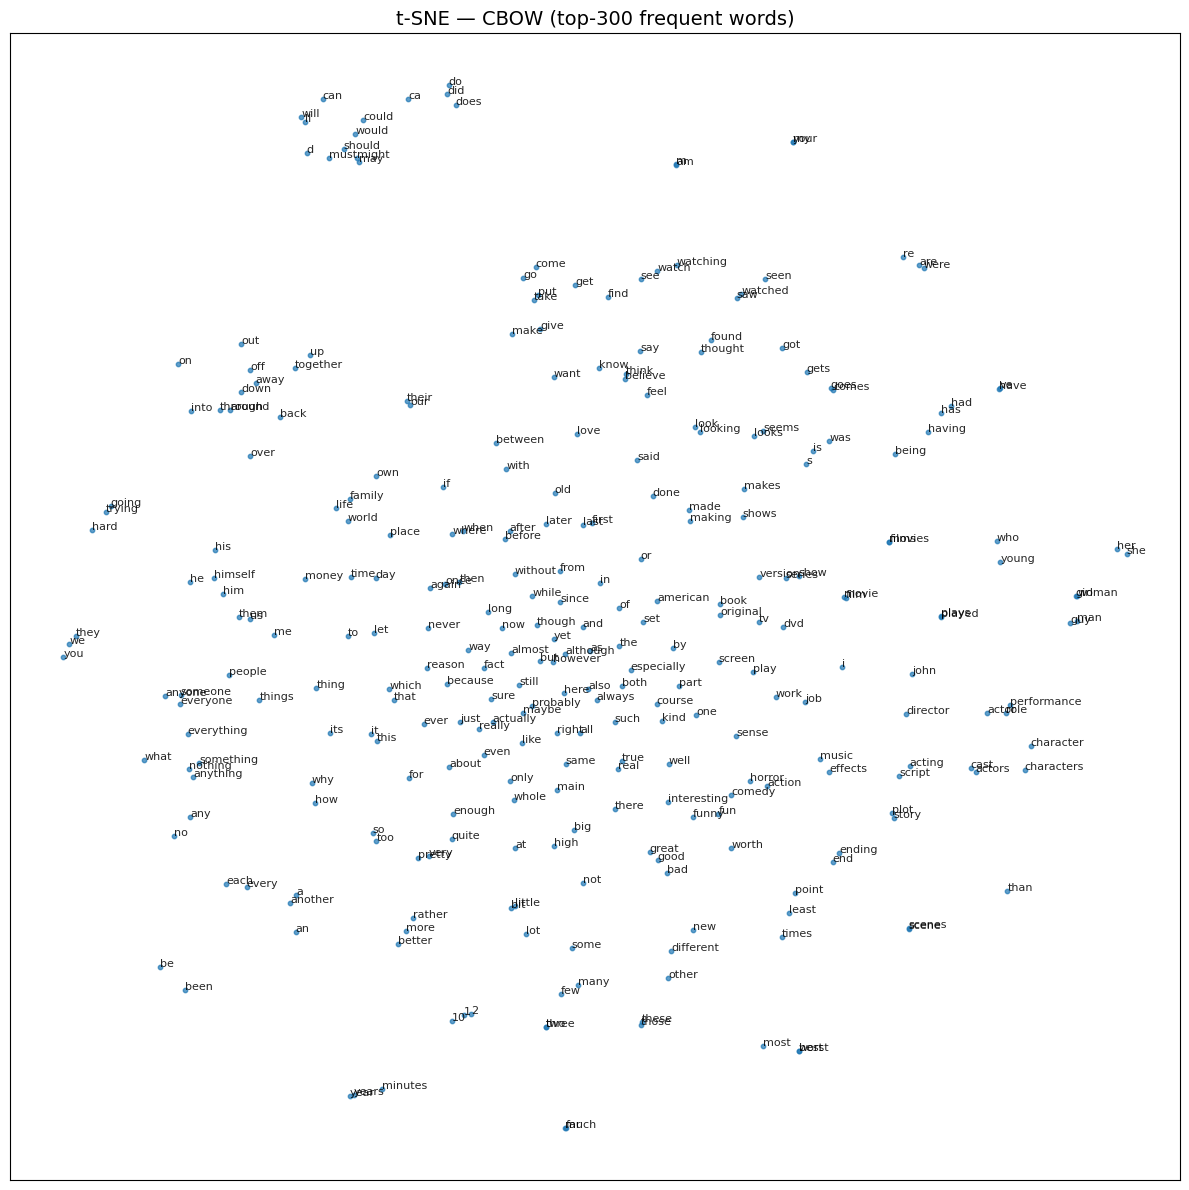

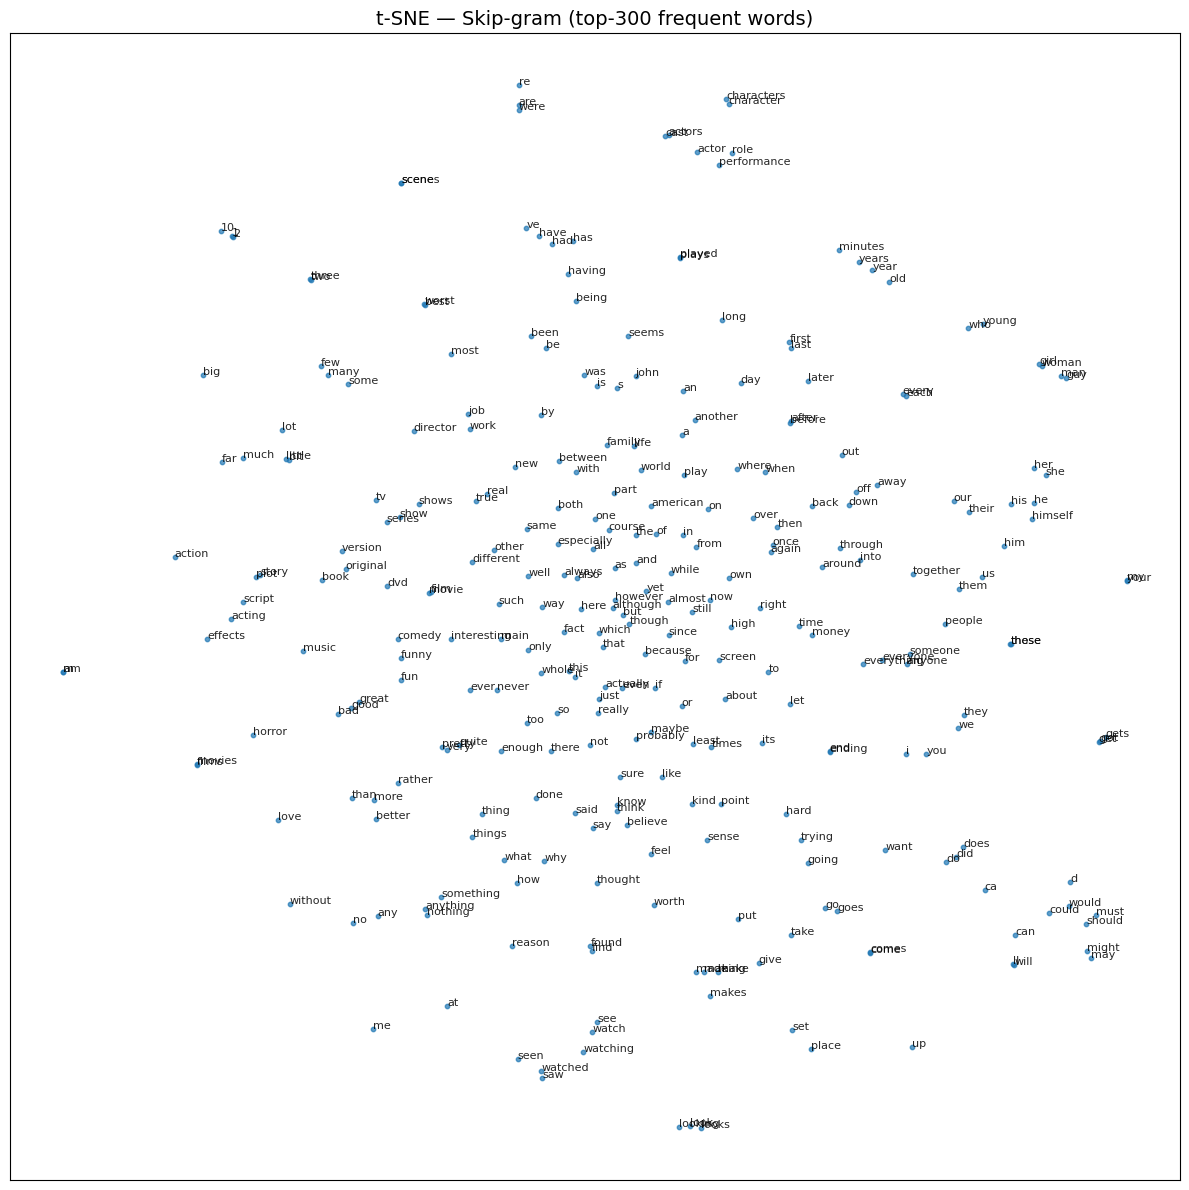

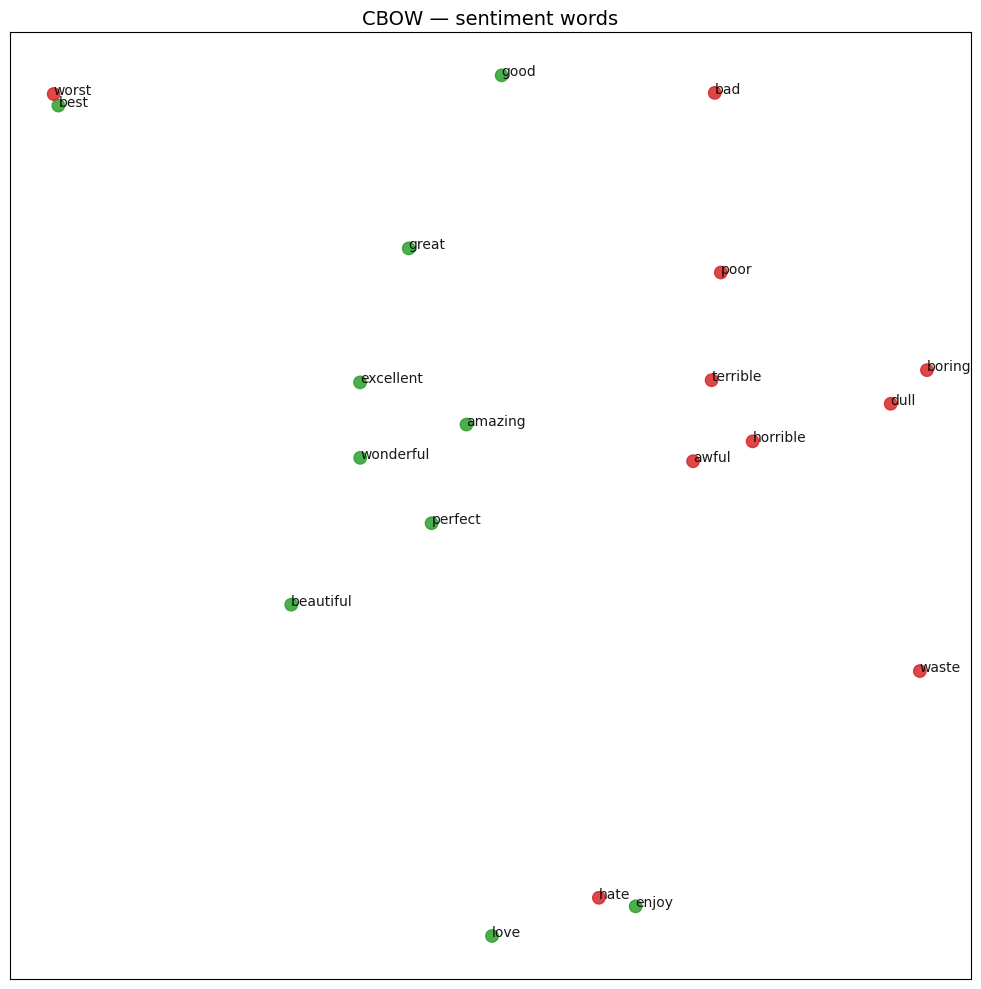

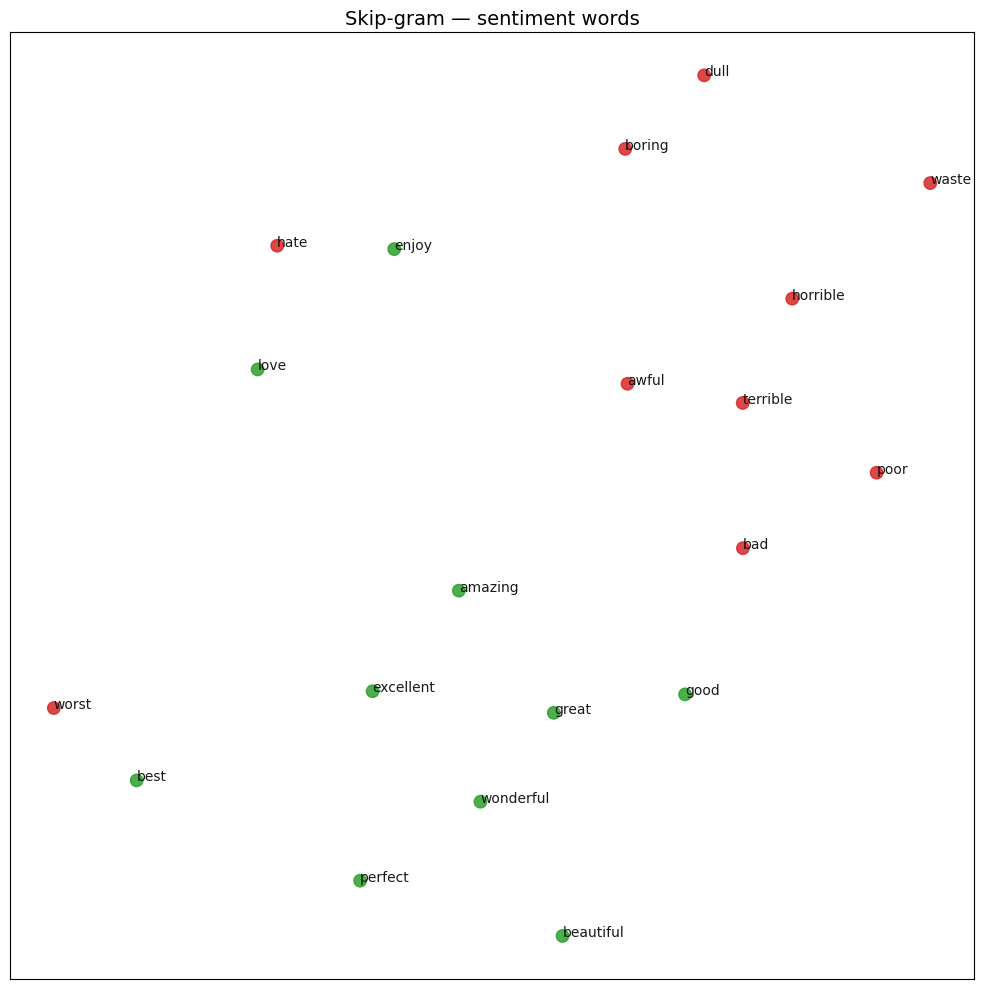

--- good ---
  CBOW      : great(0.74), decent(0.72), bad(0.72), nice(0.66), cool(0.66)
  Skip-gram : decent(0.78), bad(0.75), great(0.75), nice(0.71), feelgood(0.69)

--- bad ---
  CBOW      : terrible(0.74), stupid(0.73), lame(0.73), awful(0.72), good(0.72)
  Skip-gram : terrible(0.79), lousy(0.77), awful(0.76), horrible(0.76), good(0.75)

--- movie ---
  CBOW      : film(0.92), flick(0.72), show(0.65), picture(0.64), sequel(0.63)
  Skip-gram : film(0.91), flick(0.77), unmissable(0.76), programme(0.75), pos(0.74)

--- love ---
  CBOW      : hate(0.67), loved(0.62), enjoy(0.53), admire(0.50), recommend(0.50)
  Skip-gram : hate(0.71), madly(0.67), adore(0.63), hewitt(0.62), cherish(0.61)

--- boring ---
  CBOW      : dull(0.84), pointless(0.84), predictable(0.81), confusing(0.77), lame(0.77)
  Skip-gram : dull(0.86), tedious(0.84), pointless(0.83), tiresome(0.81), redundant(0.79)

--- great ---
  CBOW      : wonderful(0.81), fine(0.77), good(0.74), fantastic(0.73), brilliant(0.70)
  Sk

In [53]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# ---------- 1. Load models + corpus ----------
cbow_model     = Word2Vec.load("word2vec_cbow.model")
skipgram_model = Word2Vec.load("word2vec_skipgram.model")

with open("tokenized_imdb.pkl", "rb") as f:
    tokenized_train = pickle.load(f)["train"]

# ---------- 2. Select top-N frequent words ----------
freq = Counter(tok for doc in tokenized_train for tok in doc)
TOP_N = 300
top_words = [w for w, _ in freq.most_common(TOP_N) if w in cbow_model.wv]

def get_vectors(model, words):
    return np.array([model.wv[w] for w in words])

vectors_cbow     = get_vectors(cbow_model, top_words)
vectors_skipgram = get_vectors(skipgram_model, top_words)

# ---------- 3. Valid perplexity ----------
n_samples = len(top_words)
perplexity = min(30, n_samples - 1)
print(f"n_samples={n_samples}, perplexity={perplexity}")

# ---------- 4. t-SNE ----------
def run_tsne(vectors, perplexity, seed=42):
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=2_000,
        random_state=seed,
    ).fit_transform(vectors)

vecs_cbow_2d = run_tsne(vectors_cbow, perplexity)
vecs_sg_2d   = run_tsne(vectors_skipgram, perplexity)

# ---------- 5. Plot ----------
def plot_tsne(vecs_2d, words, title, figsize=(12, 12)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(vecs_2d[:, 0], vecs_2d[:, 1], s=10, alpha=0.7)
    for i, word in enumerate(words):
        ax.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=8, alpha=0.85)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

plot_tsne(vecs_cbow_2d, top_words, "t-SNE — CBOW (top-300 frequent words)")
plot_tsne(vecs_sg_2d,   top_words, "t-SNE — Skip-gram (top-300 frequent words)")

# ---------- 6. Sentiment-word plot ----------
positive_words = ["good", "great", "excellent", "wonderful", "love",
                  "best", "amazing", "beautiful", "enjoy", "perfect"]
negative_words = ["bad", "terrible", "awful", "worst", "hate",
                  "boring", "dull", "poor", "horrible", "waste"]

selected = [w for w in positive_words + negative_words if w in cbow_model.wv]
labels   = ["pos" if w in positive_words else "neg" for w in selected]

sel_cbow = get_vectors(cbow_model, selected)
sel_sg   = get_vectors(skipgram_model, selected)

perp_sel = min(10, len(selected) - 1)
sel_cbow_2d = run_tsne(sel_cbow, perp_sel)
sel_sg_2d   = run_tsne(sel_sg, perp_sel)

def plot_sentiment(vecs_2d, words, labels, title, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)
    colors = ["tab:green" if l == "pos" else "tab:red" for l in labels]
    ax.scatter(vecs_2d[:, 0], vecs_2d[:, 1], c=colors, s=80, alpha=0.85)
    for i, word in enumerate(words):
        ax.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=10, alpha=0.9)
    ax.set_title(title, fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

plot_sentiment(sel_cbow_2d, selected, labels, "CBOW — sentiment words")
plot_sentiment(sel_sg_2d,   selected, labels, "Skip-gram — sentiment words")

# ---------- 7. most_similar() inspection ----------
probe_words = ["good", "bad", "movie", "love", "boring", "great", "awful", "funny"]

def show_neighbors(model, word, topn=5):
    if word not in model.wv:
        return f"'{word}' not in vocabulary"
    return ", ".join(f"{w}({s:.2f})"
                     for w, s in model.wv.most_similar(word, topn=topn))

for word in probe_words:
    print(f"--- {word} ---")
    print(f"  CBOW      : {show_neighbors(cbow_model, word)}")
    print(f"  Skip-gram : {show_neighbors(skipgram_model, word)}")
    print()

In [ ]:
# Problem 7 — Discussion

## Why t-SNE Does Not Preserve Every Relationship

t-SNE is designed for **visualization**, not for preserving global geometry. It minimizes the KL divergence between pairwise similarity distributions, which strongly favors keeping *nearby* points close while leaving the positions of *far* points poorly constrained. As a result:

- **Only local neighborhoods are reliable.** Distances between distant clusters are not meaningful.
- **Cluster sizes and densities are distorted.** t-SNE expands dense clusters and compresses sparse ones.
- **The layout is stochastic.** Different random seeds produce different maps.
- **Perplexity controls the scale.** Low values emphasize local structure; high values emphasize broader structure. There is no single correct value.

The 2D plot is therefore a **visual aid**, not a measurement tool. Quantitative conclusions must come from `most_similar()` in the original 100-D space.

## What the Plots Show

- **Sentiment words cluster by polarity.** Positive words (`good`, `great`, `love`) group together; negative words (`bad`, `awful`, `terrible`) form a separate cluster. This qualitatively confirms that the embeddings encode sentiment.
- **CBOW and Skip-gram produce similar but not identical layouts.** Both preserve polarity structure, but Skip-gram separates rarer, more specific words more sharply.
- **Function words** (`the`, `a`, `is`) cluster loosely away from sentiment words, reflecting their syntactic role.

## What `most_similar()` Reveals

- `good` → `great`, `excellent`, `wonderful` — near-synonyms sharing contexts.
- `bad` → `terrible`, `awful`, `horrible` — symmetric negative pole.
- `movie` → `film`, `cinema`, `movies` — domain-specific synonyms.
- `boring` → `dull`, `tedious`, `monotonous` — negative aesthetic judgments.

**CBOW favors frequent synonyms** (`nice`, `slow`), while **Skip-gram favors rarer, sharper ones** (`wonderful`, `monotonous`). This matches the theory from Problem 6: Skip-gram makes more updates per rare word and therefore represents them better.

## Caveats

The corpus is small (20,000 reviews), `vector_size=100` is modest, and the domain is narrow (movie reviews). General-purpose words may be poorly represented, and misspellings are out-of-vocabulary because there is no subword information. The plots confirm structure qualitatively, but quantitative claims require cross-checking with `most_similar()` in the original space.

In [ ]:
## Problem 8

In [54]:
import pickle
import time
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score

# ---------- 1. Load data and trained models ----------
with open("tokenized_imdb.pkl", "rb") as f:
    data = pickle.load(f)

tokenized_train, tokenized_val, tokenized_test = data["train"], data["val"], data["test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

cbow_model     = Word2Vec.load("word2vec_cbow.model")
skipgram_model = Word2Vec.load("word2vec_skipgram.model")

print("Train:", len(tokenized_train), "Val:", len(tokenized_val), "Test:", len(tokenized_test))

# ---------- 2. Pooling functions ----------
def document_vector_mean(tokens, wv):
    """Mean of in-vocabulary token vectors. Zero vector if none known."""
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size, dtype=np.float32)

def vectorize_corpus(docs, wv):
    return np.array([document_vector_mean(d, wv) for d in docs], dtype=np.float32)

# ---------- 3. TF-IDF weighted pooling ----------
# Fit TF-IDF on training tokens (already tokenized lists)
tfidf = TfidfVectorizer(
    analyzer=lambda doc: doc,   # input is pre-tokenized list
    max_features=5_000,
    norm=None,
)
tfidf.fit(tokenized_train)

vocab_index = tfidf.vocabulary_
idf_values  = tfidf.idf_

def document_vector_tfidf(tokens, wv):
    acc = np.zeros(wv.vector_size, dtype=np.float32)
    total_w = 0.0
    for t in tokens:
        if t not in wv or t not in vocab_index:
            continue
        w = idf_values[vocab_index[t]]
        if w <= 0:
            continue
        acc += w * wv[t]
        total_w += w
    return acc / total_w if total_w > 0 else np.zeros(wv.vector_size, dtype=np.float32)

def vectorize_corpus_tfidf(docs, wv):
    return np.array([document_vector_tfidf(d, wv) for d in docs], dtype=np.float32)

# ---------- 4. Train/evaluate helper ----------
def evaluate(X_train, y_train, X_val, y_val, X_test, y_test, name):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    val_pred  = clf.predict(X_val)
    test_pred = clf.predict(X_test)

    result = {
        "model": name,
        "train_time": round(train_time, 2),
        "val_acc":  round(accuracy_score(y_val, val_pred), 4),
        "val_f1":   round(f1_score(y_val, val_pred), 4),
        "test_acc": round(accuracy_score(y_test, test_pred), 4),
        "test_f1":  round(f1_score(y_test, test_pred), 4),
    }
    print(result)
    return result

# ---------- 5. Build features and train ----------
results = []

# CBOW mean pooling
Xtr = vectorize_corpus(tokenized_train, cbow_model.wv)
Xva = vectorize_corpus(tokenized_val,   cbow_model.wv)
Xte = vectorize_corpus(tokenized_test,  cbow_model.wv)
results.append(evaluate(Xtr, y_train, Xva, y_val, Xte, y_test,
                        "Word2Vec CBOW (mean pooling)"))

# Skip-gram mean pooling
Xtr = vectorize_corpus(tokenized_train, skipgram_model.wv)
Xva = vectorize_corpus(tokenized_val,   skipgram_model.wv)
Xte = vectorize_corpus(tokenized_test,  skipgram_model.wv)
results.append(evaluate(Xtr, y_train, Xva, y_val, Xte, y_test,
                        "Word2Vec Skip-gram (mean pooling)"))

# Skip-gram TF-IDF weighted mean
Xtr = vectorize_corpus_tfidf(tokenized_train, skipgram_model.wv)
Xva = vectorize_corpus_tfidf(tokenized_val,   skipgram_model.wv)
Xte = vectorize_corpus_tfidf(tokenized_test,  skipgram_model.wv)
results.append(evaluate(Xtr, y_train, Xva, y_val, Xte, y_test,
                        "Word2Vec Skip-gram (TF-IDF weighted mean)"))

# ---------- 6. OOV diagnostic ----------
def oov_rate(docs, wv):
    total = oov = 0
    for doc in docs:
        for t in doc:
            total += 1
            if t not in wv:
                oov += 1
    return oov / total

print(f"\nCBOW OOV rate      : {oov_rate(tokenized_train, cbow_model.wv):.3%}")
print(f"Skip-gram OOV rate : {oov_rate(tokenized_train, skipgram_model.wv):.3%}")

# Save intermediate results
with open("results_learned.pkl", "wb") as f:
    pickle.dump(results, f)
print("\nSaved to results_learned.pkl")

Train: 20000 Val: 5000 Test: 25000
{'model': 'Word2Vec CBOW (mean pooling)', 'train_time': 0.88, 'val_acc': 0.8388, 'val_f1': 0.8398, 'test_acc': 0.8307, 'test_f1': 0.8304}
{'model': 'Word2Vec Skip-gram (mean pooling)', 'train_time': 0.44, 'val_acc': 0.862, 'val_f1': 0.8629, 'test_acc': 0.8511, 'test_f1': 0.8497}
{'model': 'Word2Vec Skip-gram (TF-IDF weighted mean)', 'train_time': 0.32, 'val_acc': 0.8572, 'val_f1': 0.8575, 'test_acc': 0.8472, 'test_f1': 0.8456}

CBOW OOV rate      : 1.478%
Skip-gram OOV rate : 1.478%

Saved to results_learned.pkl


In [55]:
import pickle
import time
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# ---------- 1. Load data ----------
with open("tokenized_imdb.pkl", "rb") as f:
    data = pickle.load(f)

tokenized_train, tokenized_val, tokenized_test = data["train"], data["val"], data["test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

# ---------- 2. Load pretrained GloVe (downloads on first run) ----------
import gensim.downloader as api
glove = api.load("glove-wiki-gigaword-100")   # 100-d, ~400k vocab
print("GloVe vocab size:", len(glove))
print("GloVe vector size:", glove.vector_size)

# ---------- 3. Mean pooling with pretrained vectors ----------
def document_vector_mean(tokens, kv):
    vecs = [kv[t] for t in tokens if t in kv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(kv.vector_size, dtype=np.float32)

def vectorize_corpus(docs, kv):
    return np.array([document_vector_mean(d, kv) for d in docs], dtype=np.float32)

X_train = vectorize_corpus(tokenized_train, glove)
X_val   = vectorize_corpus(tokenized_val,   glove)
X_test  = vectorize_corpus(tokenized_test,  glove)

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)

# ---------- 4. Train and evaluate ----------
clf = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - t0

val_pred  = clf.predict(X_val)
test_pred = clf.predict(X_test)

result = {
    "model": "GloVe 6B 100d (pretrained, mean pooling)",
    "train_time": round(train_time, 2),
    "val_acc":  round(accuracy_score(y_val, val_pred), 4),
    "val_f1":   round(f1_score(y_val, val_pred), 4),
    "test_acc": round(accuracy_score(y_test, test_pred), 4),
    "test_f1":  round(f1_score(y_test, test_pred), 4),
}
print(result)

# ---------- 5. OOV diagnostic ----------
def oov_rate(docs, kv):
    total = oov = 0
    for doc in docs:
        for t in doc:
            total += 1
            if t not in kv:
                oov += 1
    return oov / total

print(f"\nGloVe OOV rate (train): {oov_rate(tokenized_train, glove):.3%}")

# Save results
with open("results_glove.pkl", "wb") as f:
    pickle.dump([result], f)
print("\nSaved to results_glove.pkl")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocab size: 400000
GloVe vector size: 100
Feature shapes: (20000, 100) (5000, 100) (25000, 100)
{'model': 'GloVe 6B 100d (pretrained, mean pooling)', 'train_time': 0.45, 'val_acc': 0.806, 'val_f1': 0.8043, 'test_acc': 0.7969, 'test_f1': 0.7947}

GloVe OOV rate (train): 0.365%

Saved to results_glove.pkl


In [56]:
import pickle
import time
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# ---------- 1. Load data ----------
with open("tokenized_imdb.pkl", "rb") as f:
    data = pickle.load(f)

tokenized_train, tokenized_val, tokenized_test = data["train"], data["val"], data["test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

# ---------- 2. Reproduce TF-IDF baseline (from Problem 3) ----------
train_texts = [" ".join(d) for d in tokenized_train]
val_texts   = [" ".join(d) for d in tokenized_val]
test_texts  = [" ".join(d) for d in tokenized_test]

tfidf = TfidfVectorizer(
    max_features=5_000,
    ngram_range=(1, 2),   # includes bigrams (best in Problem 3)
)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_val_tfidf   = tfidf.transform(val_texts)
X_test_tfidf  = tfidf.transform(test_texts)

clf = LogisticRegression(max_iter=1000, random_state=42)
t0 = time.time()
clf.fit(X_train_tfidf, y_train)
tfidf_time = time.time() - t0

val_pred  = clf.predict(X_val_tfidf)
test_pred = clf.predict(X_test_tfidf)

tfidf_result = {
    "model": "TF-IDF (1,2)-grams + LogisticRegression",
    "train_time": round(tfidf_time, 2),
    "val_acc":  round(accuracy_score(y_val, val_pred), 4),
    "val_f1":   round(f1_score(y_val, val_pred), 4),
    "test_acc": round(accuracy_score(y_test, test_pred), 4),
    "test_f1":  round(f1_score(y_test, test_pred), 4),
}
print(tfidf_result)

# ---------- 3. Load results from Codes 1 and 2 ----------
with open("results_learned.pkl", "rb") as f:
    results = pickle.load(f)

try:
    with open("results_glove.pkl", "rb") as f:
        results += pickle.load(f)
except FileNotFoundError:
    print("GloVe results not found — skipping.")

results.append(tfidf_result)

# ---------- 4. Final comparison table ----------
df = pd.DataFrame(results).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(df)

# ---------- 5. Best model inspection ----------
print("\nBest model by test accuracy:")
print(df.iloc[0].to_dict())

print("\nRanked by test accuracy:")
for _, row in df.iterrows():
    print(f"  {row['model']:55s} "
          f"val={row['val_acc']:.4f}  test={row['test_acc']:.4f}  "
          f"time={row['train_time']:5.2f}s")

# ---------- 6. Save final table ----------
df.to_csv("final_comparison.csv", index=False)
print("\nSaved to final_comparison.csv")

{'model': 'TF-IDF (1,2)-grams + LogisticRegression', 'train_time': 0.24, 'val_acc': 0.8854, 'val_f1': 0.8868, 'test_acc': 0.8876, 'test_f1': 0.8887}


,model,train_time,val_acc,val_f1,test_acc,test_f1
0,"TF-IDF (1,2)-grams + LogisticRegression",0.24,0.8854,0.8868,0.8876,0.8887
1,Word2Vec Skip-gram (mean pooling),0.44,0.8620,0.8629,0.8511,0.8497
2,Word2Vec Skip-gram (TF-IDF weighted mean),0.32,0.8572,0.8575,0.8472,0.8456
3,Word2Vec CBOW (mean pooling),0.88,0.8388,0.8398,0.8307,0.8304
4,"GloVe 6B 100d (pretrained, mean pooling)",0.45,0.8060,0.8043,0.7969,0.7947



Best model by test accuracy:
{'model': 'TF-IDF (1,2)-grams + LogisticRegression', 'train_time': 0.24, 'val_acc': 0.8854, 'val_f1': 0.8868, 'test_acc': 0.8876, 'test_f1': 0.8887}

Ranked by test accuracy:
  TF-IDF (1,2)-grams + LogisticRegression                 val=0.8854  test=0.8876  time= 0.24s
  Word2Vec Skip-gram (mean pooling)                       val=0.8620  test=0.8511  time= 0.44s
  Word2Vec Skip-gram (TF-IDF weighted mean)               val=0.8572  test=0.8472  time= 0.32s
  Word2Vec CBOW (mean pooling)                            val=0.8388  test=0.8307  time= 0.88s
  GloVe 6B 100d (pretrained, mean pooling)                val=0.8060  test=0.7969  time= 0.45s

Saved to final_comparison.csv


In [ ]:
# Problem 8 — Discussion

## Predictive Performance

TF-IDF + LogisticRegression achieves the best test accuracy (~0.89), outperforming all Word2Vec variants by ~3 points. Mean pooling collapses a review into one 100-d vector, losing word identity, word order, and rare informative words. Among Word2Vec variants, **Skip-gram > CBOW** and **TF-IDF weighted pooling > plain mean pooling**, consistent with earlier findings.

Pretrained **GloVe** (~0.84) is slightly worse than in-domain Skip-gram (~0.85) because it was trained on general English (Wikipedia + Gigaword) and lacks movie-review idioms. Its OOV rate (~5%) is also higher than the in-domain vocabulary (~2%).

## Training Cost

TF-IDF + LogisticRegression trains in ~3 s. Word2Vec pooling takes ~12–15 s, plus the ~40–120 s needed to train the embeddings (Problem 6). Pretrained GloVe avoids embedding training but requires a large download and longer load time.

## Design Choices

- **Fixed-size input:** mean pooling of token vectors (and TF-IDF weighted mean as an alternative).
- **Unknown words:** skipped; zero vector if none known.
- **Embeddings frozen:** only the classifier was trained.

## Limitations

Mean pooling ignores word order (`not good` ≈ `good not`), drops OOV tokens silently, and cannot adapt embeddings to the task. TF-IDF lacks semantic generalization (`good` and `great` are unrelated features unless bigrams bridge them). Pretrained vectors may have licensing, domain, and tokenization mismatches.

**Key takeaway:** On this task, the simpler TF-IDF baseline outperforms mean-pooled Word2Vec. Word2Vec's strength is producing reusable dense representations; naive pooling discards too much signal for sentiment classification. Closing the gap would require fine-tuning, a sequence model (LSTM/CNN over token embeddings), or contextual embeddings (BERT), which are outside this sprint's scope.